<a href="https://colab.research.google.com/github/ivan-block/Traffic-signs-classification/blob/main/traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers, models
from keras.preprocessing import image
import numpy as np

In [71]:
img_size = (64, 64)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "traffic",                # path to your folder
    validation_split=0.2,     # 20% validation
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "traffic",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.


In [72]:
train_data = train_data.map(lambda x, y: (x / 255.0, y))
val_data = val_data.map(lambda x, y: (x / 255.0, y))

In [73]:
traffic = tf.keras.preprocessing.image_dataset_from_directory(
    'traffic',
    image_size=img_size,
    batch_size=batch_size
)

class_names = traffic.class_names
print("Classes:", class_names)

Found 200 files belonging to 2 classes.
Classes: ['Green', 'Red']


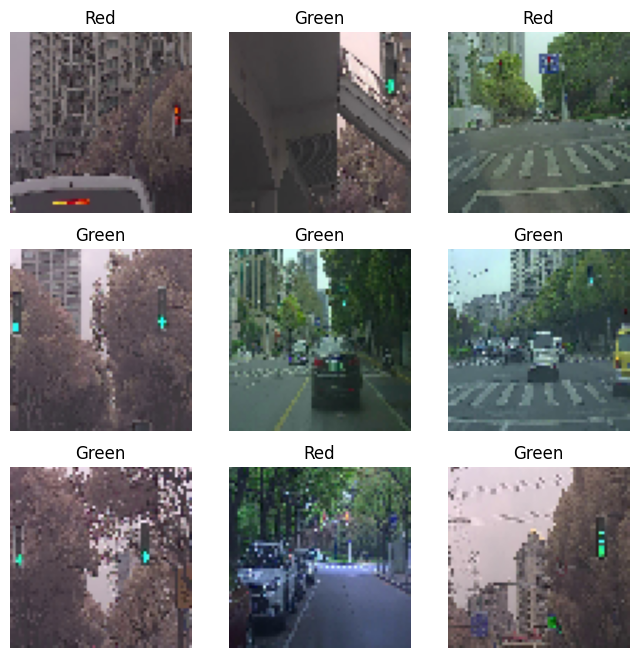

In [74]:
plt.figure(figsize=(8, 8))

for images, labels in traffic.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [75]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 394ms/step - accuracy: 0.5813 - loss: 0.6801 - val_accuracy: 0.5000 - val_loss: 0.7045
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - accuracy: 0.5000 - loss: 0.7021 - val_accuracy: 0.5000 - val_loss: 0.6903
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5875 - loss: 0.6891 - val_accuracy: 0.5000 - val_loss: 0.6909
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 356ms/step - accuracy: 0.5063 - loss: 0.6905 - val_accuracy: 0.5250 - val_loss: 0.6863
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - accuracy: 0.5750 - loss: 0.6835 - val_accuracy: 0.8500 - val_loss: 0.6791
Epoch 6/10


In [ ]:
model.evaluate(val_data)

In [ ]:
img = image.load_img("traffic/Green/000503.jpg", target_size=(64,64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Red sign")
else:
    print("Green sign")